# Notebook 8: Matplotlib — The Foundation
### ML Skills Refresh Curriculum — Module 8 of 30
#### Module 3: Data Visualisation Masterclass — Notebook 1 of 3

---

## 🎯 Learning Objectives

| # | Topic | Why It Matters in ML |
|---|-------|----------------------|
| 1 | State-based vs Object-Oriented interface | The OO interface is the only viable choice for production plots and multi-panel figures |
| 2 | The `Figure` / `Axes` / `Artist` hierarchy | Understanding the structure prevents every unexplained layout bug you will ever have |
| 3 | Line plot | Visualising training loss curves, time-series features, learning rate schedules |
| 4 | Scatter plot | Exploring feature-target relationships, plotting 2-D embeddings (PCA, t-SNE) |
| 5 | Bar chart | Comparing feature importances, class distributions, model metric comparisons |
| 6 | Histogram | Understanding feature distributions before choosing a scaler or imputation strategy |
| 7 | Customisation toolkit | Titles, labels, legends, colours, spines, gridlines — making plots publication-ready |

---

> **Datasets:** Each plot type uses its own purpose-built dummy dataset, explicitly chosen to make the plot type intuitive:
> - **Line plot** — 12 months of website traffic (time-series)
> - **Scatter plot** — study hours vs exam scores (correlated numeric data)
> - **Bar chart** — model accuracy comparison across five classifiers (categorical)
> - **Histogram** — synthetic heights of 500 people (continuous distribution)

---
## Section 1 — Two Interfaces: State-Based vs Object-Oriented

### 📖 The Logic — Before Any Code

Matplotlib was written in 2003 and designed to feel like MATLAB. Over time, two ways of using it emerged — and understanding the difference saves hours of confusion.

---

### Interface A — State-Based (MATLAB style)

```python
import matplotlib.pyplot as plt
plt.plot([1, 2, 3], [4, 5, 6])
plt.title("My Plot")
plt.show()
```

Matplotlib keeps a hidden **"current figure"** and **"current axes"** in memory. Every `plt.something()` call silently operates on whatever is currently active. This is convenient for one-liners but becomes unmanageable the moment you have multiple subplots — you lose track of which axes you are drawing on.

---

### Interface B — Object-Oriented (OO style)

```python
fig, ax = plt.subplots()   # explicitly create figure AND axes
ax.plot([1, 2, 3], [4, 5, 6])
ax.set_title("My Plot")
plt.show()
```

You explicitly create a `Figure` object (`fig`) and one or more `Axes` objects (`ax`). Every operation is called **directly on the object** — no hidden state. You always know exactly which subplot you are configuring.

---

### Why the OO interface is always preferred

| Scenario | State-based result | OO result |
|----------|-------------------|----------|
| Single plot in a notebook | Works fine | Works fine |
| 4-subplot figure | Easy to accidentally draw on the wrong axes | Each `ax` is an explicit variable — no ambiguity |
| Plots inside functions | State leaks between calls | Each call creates its own isolated `fig, ax` |
| Saving a specific subplot | Fragile | `fig.savefig()` saves exactly what you built |
| Reading others' ML code | plt-style is common in snippets | OO is universal in production ML repos |

**Rule:** Use `plt.subplots()` from the first line of every plot. Only use `plt.show()` and `plt.savefig()` — nothing else from the `plt.*` namespace once you have an `ax` handle.

---

### The Figure / Axes Hierarchy

```
Figure  ← the entire canvas (the window / image file)
  └── Axes  ← one individual plot panel (has its own x-axis, y-axis, title)
        ├── XAxis  (tick marks, tick labels, axis label)
        ├── YAxis
        ├── Title
        ├── Lines / Patches / Collections  ← the actual drawn data
        └── Legend
```

A Figure can contain **multiple Axes** (subplots). Each Axes is completely independent.

**The naming quirk:** the object is called `Axes` (plural) even when it represents a single plot panel. This is a historical accident — do not let it confuse you.

In [ ]:
import matplotlib.pyplot as plt       # the core plotting library
import matplotlib.gridspec as gridspec # fine-grained multi-panel layouts
import numpy as np                     # array operations for generating data
import pandas as pd                    # for the bar-chart dataset

# Set a global style for all plots in this notebook
plt.style.use("seaborn-v0_8-whitegrid")  # clean white background with subtle grid

# Set the default figure DPI for crisp output in Jupyter
plt.rcParams["figure.dpi"] = 110

np.random.seed(42)   # reproducible random data across the notebook
print(f"Matplotlib version: {plt.matplotlib.__version__}")

Matplotlib version: 3.10.0


---
## Section 2 — Side-by-Side Comparison: State-Based vs OO

Before building any real plots, let's put both interfaces next to each other on the same data so the structural difference is unmistakable.

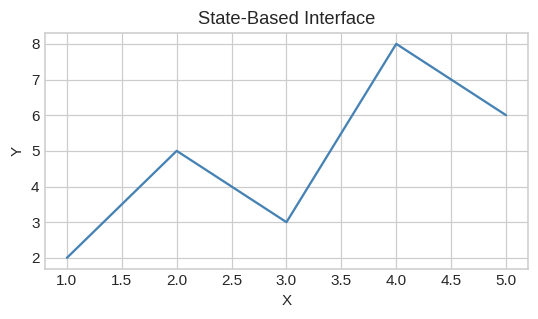

— Above: state-based. The plt.* calls implicitly target whatever axes is 'current'.
  This works fine for a single plot. It breaks down with multiple subplots.



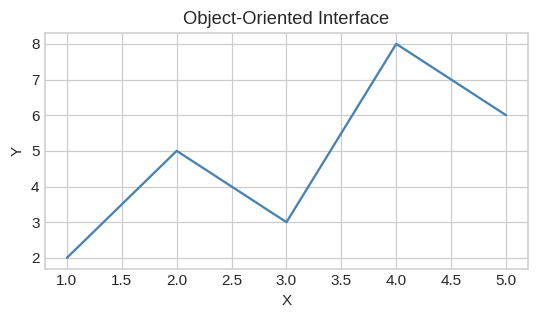

— Above: OO interface. ax.set_*() methods always target this specific axes.
  This scales cleanly to 1 or 20 subplots without any ambiguity.


In [ ]:
x = [1, 2, 3, 4, 5]
y = [2, 5, 3, 8, 6]

# ════════════════════════════════════════════════════════
#  Interface A — State-Based
#  plt.* functions act on a hidden 'current axes'
# ════════════════════════════════════════════════════════
plt.figure(figsize=(5, 3))    # create a figure (optional; plt.plot auto-creates one)
plt.plot(x, y, color="steelblue")  # draw on hidden current axes
plt.title("State-Based Interface")  # set title on hidden current axes
plt.xlabel("X")               # set x-label on hidden current axes
plt.ylabel("Y")               # set y-label on hidden current axes
plt.tight_layout()
plt.show()                    # render and clear the hidden state

print("— Above: state-based. The plt.* calls implicitly target whatever axes is 'current'.")
print("  This works fine for a single plot. It breaks down with multiple subplots.\n")

# ════════════════════════════════════════════════════════
#  Interface B — Object-Oriented (what we will always use)
#  fig and ax are explicit Python objects — no hidden state
# ════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(5, 3))  # returns (Figure, Axes) explicitly
ax.plot(x, y, color="steelblue")        # draw on THIS specific ax object
ax.set_title("Object-Oriented Interface")  # 'set_' prefix — method on ax
ax.set_xlabel("X")                      # set x-label on THIS ax
ax.set_ylabel("Y")                      # set y-label on THIS ax
fig.tight_layout()                      # adjust spacing — called on fig
plt.show()

print("— Above: OO interface. ax.set_*() methods always target this specific axes.")
print("  This scales cleanly to 1 or 20 subplots without any ambiguity.")

---
## Section 3 — Plot Type 1: Line Plot

### 📖 The Logic

A **line plot** connects ordered data points with straight line segments. It is the natural choice whenever the x-axis represents a **continuous or ordered sequence** — time, epoch number, iteration count — and the y-axis represents a value that changes along that sequence.

**In ML:** training loss curves, validation accuracy curves, learning rate schedules, and any time-series feature are all line plots.

**Dataset:** Monthly unique website visitors over 12 months for two competing products (Product A and Product B). We also overlay a 3-month rolling average to show trend smoothing.

In [ ]:
# ── Generate the time-series dataset ─────────────────────────────────────────
months     = ["Jan","Feb","Mar","Apr","May","Jun",
              "Jul","Aug","Sep","Oct","Nov","Dec"]
month_idx  = np.arange(12)   # numeric x positions for rolling average

# Product A: steady growth with some noise
visitors_a = np.array([4200, 4800, 5100, 5600, 6200, 7100,
                        7400, 7800, 7200, 8100, 8900, 9500])

# Product B: initially lower but accelerates in H2
visitors_b = np.array([3100, 3300, 3500, 3800, 4400, 5200,
                        6300, 7600, 8200, 8700, 9100, 9800])

# 3-month rolling average for Product A — smooth out noise to show trend
# np.convolve with a uniform kernel divides by window size (manual rolling mean)
window     = 3
kernel     = np.ones(window) / window               # [1/3, 1/3, 1/3]
rolling_a  = np.convolve(visitors_a, kernel, mode="valid")  # length = 12 - 3 + 1 = 10
roll_x     = np.arange(window - 1, 12)              # x positions for rolling values

print("Monthly visitors:")
for m, a, b in zip(months, visitors_a, visitors_b):
    print(f"  {m:>3}  Product A: {a:,}   Product B: {b:,}")

Monthly visitors:
  Jan  Product A: 4,200   Product B: 3,100
  Feb  Product A: 4,800   Product B: 3,300
  Mar  Product A: 5,100   Product B: 3,500
  Apr  Product A: 5,600   Product B: 3,800
  May  Product A: 6,200   Product B: 4,400
  Jun  Product A: 7,100   Product B: 5,200
  Jul  Product A: 7,400   Product B: 6,300
  Aug  Product A: 7,800   Product B: 7,600
  Sep  Product A: 7,200   Product B: 8,200
  Oct  Product A: 8,100   Product B: 8,700
  Nov  Product A: 8,900   Product B: 9,100
  Dec  Product A: 9,500   Product B: 9,800


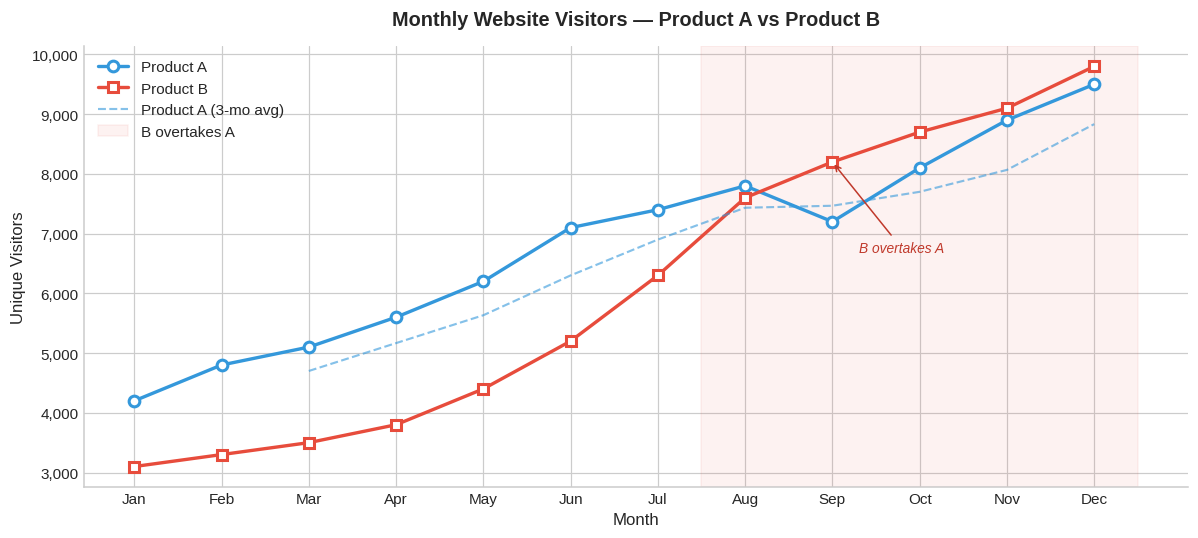


📊 Reading the chart:
  Both products grow over the year, but Product B starts slower and
  then accelerates sharply in H2 — crossing Product A around August.
  The dashed line shows that Product A's 3-month rolling average is
  smoother than its raw values, which is typical of real traffic data.



In [ ]:
# ── Line Plot — with full customisation ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))   # create Figure and Axes

# ── Draw Product A line ───────────────────────────────────────────────────────
ax.plot(
    month_idx,           # x: numeric positions (0–11)
    visitors_a,          # y: visitor counts
    color="#3498db",     # hex colour for the line
    linewidth=2.2,       # line thickness in points
    marker="o",          # marker shape at each data point
    markersize=7,        # marker size in points
    markerfacecolor="white",    # hollow circle: white fill
    markeredgecolor="#3498db",  # circle border matches line colour
    markeredgewidth=2,
    label="Product A"    # label used in the legend
)

# ── Draw Product B line ───────────────────────────────────────────────────────
ax.plot(
    month_idx,
    visitors_b,
    color="#e74c3c",
    linewidth=2.2,
    marker="s",          # square markers for visual distinction
    markersize=7,
    markerfacecolor="white",
    markeredgecolor="#e74c3c",
    markeredgewidth=2,
    label="Product B"
)

# ── Draw 3-month rolling average for Product A ────────────────────────────────
ax.plot(
    roll_x,
    rolling_a,
    color="#3498db",     # same colour as Product A
    linewidth=1.4,
    linestyle="--",      # dashed line to distinguish from raw data
    alpha=0.6,           # semi-transparent so it doesn't clutter
    label="Product A (3-mo avg)"
)

# ── Shade the region where B overtakes A ─────────────────────────────────────
# axvspan highlights a vertical band between x=6 (July) and x=11 (Dec)
ax.axvspan(
    6.5, 11.5,              # x start and end of shaded region
    alpha=0.07,             # very light fill
    color="#e74c3c",
    label="B overtakes A"
)
ax.annotate(
    "B overtakes A",
    xy=(8, 8200),            # the point to annotate
    xytext=(8.3, 6700),      # where the annotation text sits
    arrowprops=dict(arrowstyle="->", color="#c0392b"),
    fontsize=9, color="#c0392b", fontstyle="italic"
)

# ── Axis labels, title, ticks ────────────────────────────────────────────────
ax.set_title("Monthly Website Visitors — Product A vs Product B",
             fontsize=13, fontweight="bold", pad=14)   # pad= space above plot
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Unique Visitors", fontsize=11)

# Replace numeric x-ticks with month abbreviations
ax.set_xticks(month_idx)                    # set tick positions
ax.set_xticklabels(months, fontsize=10)     # replace numbers with labels

# Format y-axis with comma thousands separator
ax.yaxis.set_major_formatter(
    plt.matplotlib.ticker.FuncFormatter(lambda x, _: f"{int(x):,}")
)

# ── Legend ────────────────────────────────────────────────────────────────────
ax.legend(
    loc="upper left",     # position: upper-left corner
    fontsize=10,
    framealpha=0.9,       # legend box background opacity
    edgecolor="#cccccc"   # legend box border colour
)

# ── Remove top and right spines for a cleaner look ────────────────────────────
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()   # auto-adjust padding so labels don't get clipped
plt.show()

print("""
📊 Reading the chart:
  Both products grow over the year, but Product B starts slower and
  then accelerates sharply in H2 — crossing Product A around August.
  The dashed line shows that Product A's 3-month rolling average is
  smoother than its raw values, which is typical of real traffic data.
""")

---
## Section 4 — Plot Type 2: Scatter Plot

### 📖 The Logic

A **scatter plot** places each observation as a point at coordinates `(x, y)`. It is the primary tool for exploring the **relationship between two continuous variables** before deciding whether to use them as features or how to engineer them.

**In ML:** feature-target correlation plots, 2-D PCA/t-SNE projections of high-dimensional embeddings, predicted vs actual residual plots.

**Dataset:** 80 students — each with `hours_studied` and `exam_score`. We add a third variable (`stress_level`) encoded as marker colour to demonstrate how scatter plots can carry three dimensions of information simultaneously.

In [ ]:
# ── Generate correlated student performance data ──────────────────────────────
n = 80

# hours_studied: uniformly distributed from 1 to 10
hours = np.random.uniform(1, 10, n)

# exam_score: positively correlated with hours, plus Gaussian noise
# base: 40 + 6*hours means a student who studies 0 hrs gets ~40, 10 hrs gets ~100
scores = 40 + 6 * hours + np.random.normal(0, 8, n)
scores = np.clip(scores, 0, 100)    # clamp: scores cannot exceed 100 or go below 0

# stress_level: inversely correlated with scores (busier students → more stress)
# high stress = low value (1) so the colour scale is intuitive
stress = np.clip(10 - hours + np.random.normal(0, 1.5, n), 1, 10).round(1)

print(f"Dataset: {n} students")
print(f"Hours studied : min={hours.min():.1f}  max={hours.max():.1f}  mean={hours.mean():.1f}")
print(f"Exam scores   : min={scores.min():.1f}  max={scores.max():.1f}  mean={scores.mean():.1f}")

Dataset: 80 students
Hours studied : min=1.0  max=9.9  mean=5.2
Exam scores   : min=33.9  max=100.0  mean=70.6


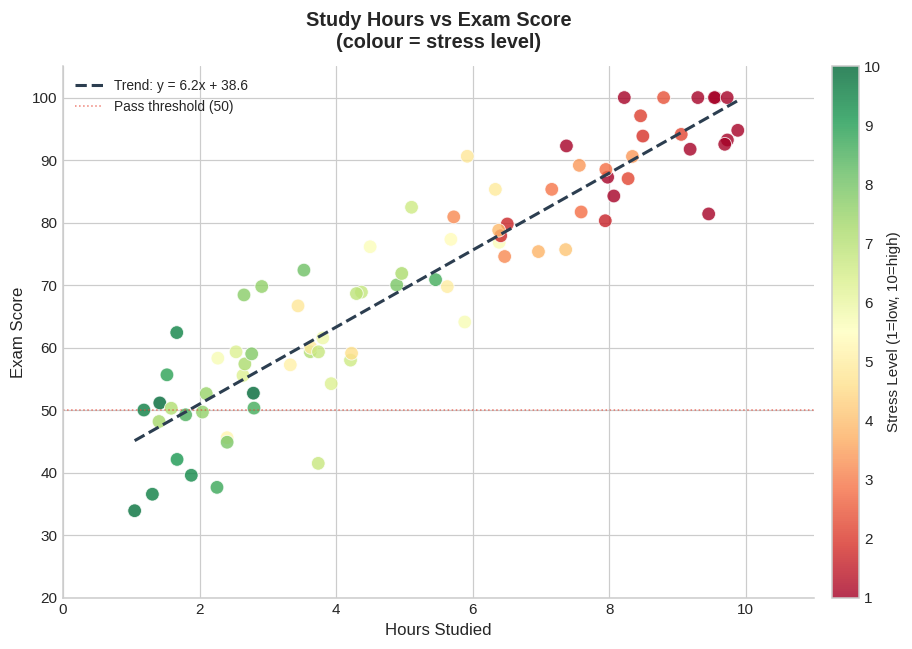

Pearson correlation (hours vs score): r = 0.923
Trend line slope: 6.16 marks per additional study hour

📊 Reading the chart:
  The dashed trend line confirms a positive correlation — more hours → higher score.
  The colour dimension reveals that high-stress students (red, top-left area)
  tend to study less and score lower, while low-stress students (green)
  cluster toward the top-right. Three variables, one plot.



In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

# ── ax.scatter(): draw the data points ───────────────────────────────────────
sc = ax.scatter(
    hours,              # x values
    scores,             # y values
    c=stress,           # map 'stress' values to colours via colormap
    cmap="RdYlGn",      # Red(high stress) → Yellow → Green(low stress)
    s=80,               # marker area in points² (NOT radius)
    alpha=0.80,         # slight transparency so overlapping points are visible
    edgecolors="white", # white ring around each marker for visual separation
    linewidths=0.6,
    vmin=1, vmax=10     # pin the colour scale min and max
)

# ── Add a colorbar to decode the colour dimension ────────────────────────────
cbar = fig.colorbar(sc, ax=ax, pad=0.02)   # sc is the PathCollection from scatter()
cbar.set_label("Stress Level (1=low, 10=high)", fontsize=10)

# ── Overlay a trend line (linear regression via np.polyfit) ──────────────────
# np.polyfit(x, y, deg=1) returns [slope, intercept] for a degree-1 polynomial
slope, intercept = np.polyfit(hours, scores, 1)   # fit y = slope*x + intercept
x_line = np.linspace(hours.min(), hours.max(), 100)  # 100 evenly spaced x values
y_line = slope * x_line + intercept                  # compute y for each x

ax.plot(
    x_line, y_line,
    color="#2c3e50",
    linewidth=2,
    linestyle="--",
    label=f"Trend: y = {slope:.1f}x + {intercept:.1f}"
)

# ── Reference lines at key thresholds ────────────────────────────────────────
ax.axhline(50, color="#e74c3c", linewidth=1, linestyle=":", alpha=0.7,
           label="Pass threshold (50)")

# ── Customisation ─────────────────────────────────────────────────────────────
ax.set_title("Study Hours vs Exam Score\n(colour = stress level)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Hours Studied", fontsize=11)
ax.set_ylabel("Exam Score", fontsize=11)
ax.set_xlim(0, 11)
ax.set_ylim(20, 105)

ax.legend(loc="upper left", fontsize=9, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()

# ── Print correlation coefficient for confirmation ───────────────────────────
corr = np.corrcoef(hours, scores)[0, 1]   # Pearson r — off-diagonal of 2×2 matrix
print(f"Pearson correlation (hours vs score): r = {corr:.3f}")
print(f"Trend line slope: {slope:.2f} marks per additional study hour")
print("""
📊 Reading the chart:
  The dashed trend line confirms a positive correlation — more hours → higher score.
  The colour dimension reveals that high-stress students (red, top-left area)
  tend to study less and score lower, while low-stress students (green)
  cluster toward the top-right. Three variables, one plot.
""")

---
## Section 5 — Plot Type 3: Bar Chart

### 📖 The Logic

A **bar chart** maps a **categorical variable** to the height of a rectangle. It answers the question *"How big is each category relative to the others?"* and is appropriate whenever the x-axis represents discrete, unordered groups rather than a continuous sequence.

**In ML:** comparing test accuracy across model architectures, visualising feature importances from a Random Forest, displaying class imbalance in a target column, showing per-class precision and recall.

**Dataset:** Five common classifiers — their test accuracy and F1 score on a hypothetical binary classification task. We show both metrics side by side as a grouped bar chart.

In [ ]:
# ── Model comparison dataset ──────────────────────────────────────────────────
models    = ["Logistic\nRegression", "Decision\nTree", "Random\nForest",
             "Gradient\nBoosting",   "SVM"]

# Hypothetical performance metrics on a test set
accuracy  = np.array([0.831, 0.784, 0.912, 0.923, 0.878])
f1_score  = np.array([0.819, 0.771, 0.905, 0.918, 0.865])

df_models = pd.DataFrame({"model": models,
                           "accuracy": accuracy,
                           "f1_score": f1_score})

print("── Model Performance Summary ──")
print(df_models.to_string(index=False))

── Model Performance Summary ──
               model  accuracy  f1_score
Logistic\nRegression     0.831     0.819
      Decision\nTree     0.784     0.771
      Random\nForest     0.912     0.905
  Gradient\nBoosting     0.923     0.918
                 SVM     0.878     0.865


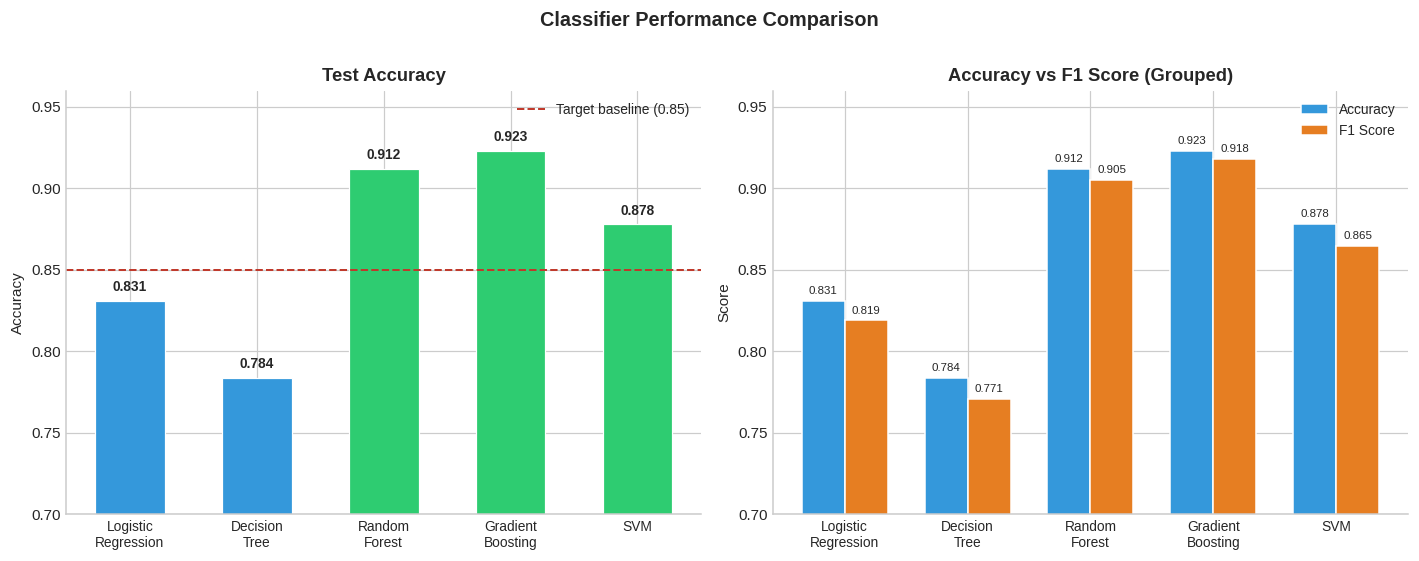


📊 Reading the charts:
  Left — Gradient Boosting and Random Forest (green) both clear the 0.85 baseline;
          the others (blue) fall short. Simple colouring by condition makes
          the threshold immediately visible.
  Right — Accuracy and F1 are very close for all models, confirming the dataset
          is reasonably balanced (no strong class imbalance distorting accuracy).
          Gradient Boosting leads on both metrics.



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))   # 1 row, 2 side-by-side subplots
fig.suptitle("Classifier Performance Comparison",
             fontsize=13, fontweight="bold", y=1.01)

# ── Panel Left: Simple vertical bar chart — Accuracy ─────────────────────────
ax_left = axes[0]

x = np.arange(len(models))    # numeric positions: 0, 1, 2, 3, 4

# Colour each bar based on whether it beats a baseline (0.85 accuracy)
bar_colours = ["#2ecc71" if a >= 0.85 else "#3498db" for a in accuracy]

bars = ax_left.bar(
    x,                   # x positions
    accuracy,            # bar heights
    width=0.55,          # bar width (0–1; 1 = bars touching)
    color=bar_colours,
    edgecolor="white",
    linewidth=0.8
)

# Annotate each bar with its exact value
for bar, val in zip(bars, accuracy):
    ax_left.text(
        bar.get_x() + bar.get_width() / 2,   # x: horizontal centre of bar
        bar.get_height() + 0.004,             # y: just above the bar top
        f"{val:.3f}",
        ha="center", va="bottom",
        fontsize=9, fontweight="bold"
    )

# Dashed baseline at 0.85 — models above it are coloured green
ax_left.axhline(0.85, color="#c0392b", linestyle="--", linewidth=1.3,
                label="Target baseline (0.85)")

ax_left.set_title("Test Accuracy", fontweight="bold")
ax_left.set_xticks(x)
ax_left.set_xticklabels(models, fontsize=9)
ax_left.set_ylim(0.70, 0.96)   # zoom y-axis to the relevant range
ax_left.set_ylabel("Accuracy")
ax_left.legend(fontsize=9)
ax_left.spines["top"].set_visible(False)
ax_left.spines["right"].set_visible(False)

# ── Panel Right: Grouped bar chart — Accuracy vs F1 Score ────────────────────
ax_right = axes[1]

width = 0.35                           # width of each bar in a pair

# Offset the two groups: accuracy bars shifted left, f1 bars shifted right
bars_acc = ax_right.bar(
    x - width / 2,     # shift left by half-width
    accuracy,
    width,
    label="Accuracy",
    color="#3498db",
    edgecolor="white"
)
bars_f1 = ax_right.bar(
    x + width / 2,     # shift right by half-width
    f1_score,
    width,
    label="F1 Score",
    color="#e67e22",
    edgecolor="white"
)

# Annotate both sets of bars
for bar in list(bars_acc) + list(bars_f1):   # iterate over all bars in both groups
    ax_right.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.003,
        f"{bar.get_height():.3f}",
        ha="center", va="bottom", fontsize=7.5
    )

ax_right.set_title("Accuracy vs F1 Score (Grouped)", fontweight="bold")
ax_right.set_xticks(x)
ax_right.set_xticklabels(models, fontsize=9)
ax_right.set_ylim(0.70, 0.96)
ax_right.set_ylabel("Score")
ax_right.legend(fontsize=9)
ax_right.spines["top"].set_visible(False)
ax_right.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()

print("""
📊 Reading the charts:
  Left — Gradient Boosting and Random Forest (green) both clear the 0.85 baseline;
          the others (blue) fall short. Simple colouring by condition makes
          the threshold immediately visible.
  Right — Accuracy and F1 are very close for all models, confirming the dataset
          is reasonably balanced (no strong class imbalance distorting accuracy).
          Gradient Boosting leads on both metrics.
""")

---
## Section 6 — Plot Type 4: Histogram

### 📖 The Logic

A **histogram** divides a continuous variable into equal-width **bins** and counts how many observations fall into each bin. It shows the **shape of a distribution** — whether data is symmetric, skewed, bimodal, or heavy-tailed.

**In ML:** before choosing a feature scaler, you inspect whether the distribution is symmetric (→ StandardScaler) or skewed (→ RobustScaler or log-transform). Before imputing missing values, you check whether the median or mean is more representative. Histograms answer these questions visually in seconds.

**Dataset:** Simulated heights of 500 people drawn from two overlapping normal distributions — a mixture distribution that produces a subtly bimodal shape, mimicking real demographic data.

**Key parameter — `bins`:**
- Too few bins → plot is blocky, details are hidden
- Too many bins → plot is spiky, noise dominates
- Rule of thumb: `bins = int(√n)` or use `bins='auto'` (Sturges/Scott heuristic)

In [ ]:
# ── Generate mixture distribution (two overlapping Gaussians) ────────────────
n_total = 500

# Group A: 55% of people — mean 168 cm, std 7 cm
group_a = np.random.normal(loc=168, scale=7, size=int(n_total * 0.55))

# Group B: 45% of people — mean 178 cm, std 8 cm
group_b = np.random.normal(loc=178, scale=8, size=int(n_total * 0.45))

# Combine both groups into one population array
heights = np.concatenate([group_a, group_b])

print(f"Population: {len(heights)} people")
print(f"Mean   : {heights.mean():.1f} cm")
print(f"Median : {np.median(heights):.1f} cm")
print(f"Std    : {heights.std():.1f} cm")
print(f"Range  : {heights.min():.1f} – {heights.max():.1f} cm")

Population: 500 people
Mean   : 172.4 cm
Median : 172.1 cm
Std    : 8.8 cm
Range  : 145.3 – 198.6 cm


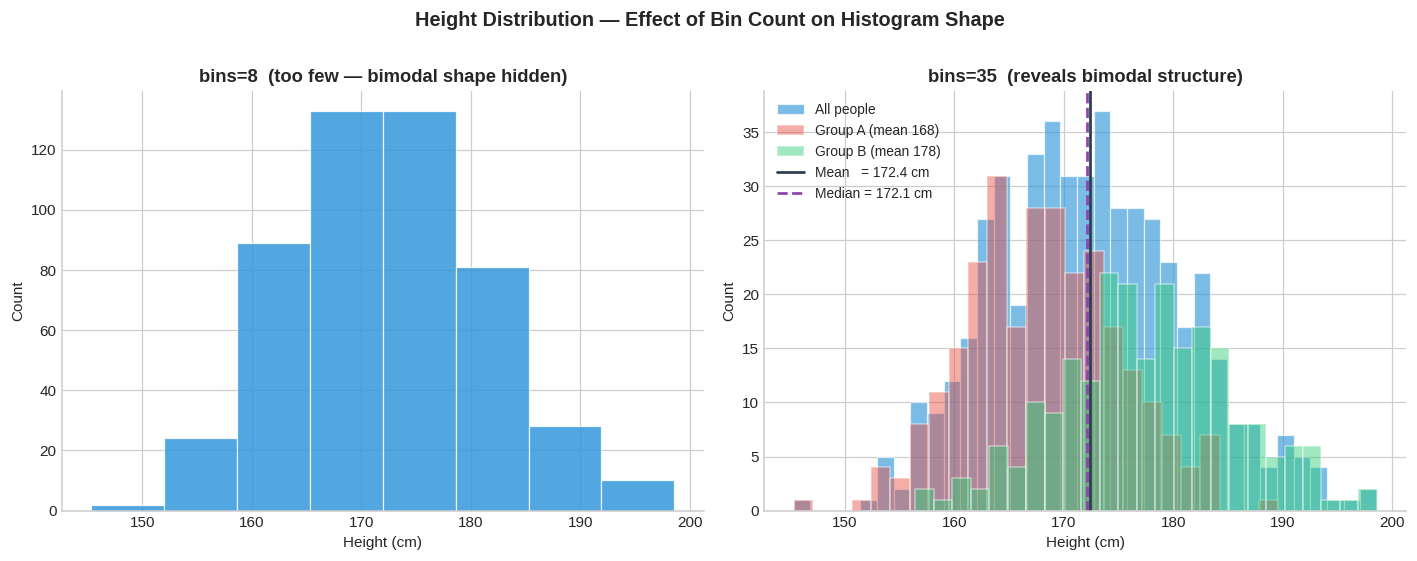


📊 Reading the charts:
  Left  — With only 8 bins the two peaks merge into one broad lump. You would
           incorrectly conclude the distribution is roughly symmetric.
  Right — With 35 bins the bimodal structure is clearly visible (two humps).
           The overlaid sub-groups show exactly which population produces each peak.
           The mean (solid) and median (dashed) are very close — typical of a
           near-symmetric bimodal distribution.

  ML implication: if you saw this distribution for a real feature, you would
  consider whether the two groups should be modelled separately, or whether a
  'group_flag' binary feature would add predictive power.



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Height Distribution — Effect of Bin Count on Histogram Shape",
             fontsize=13, fontweight="bold", y=1.01)

# ── Panel Left: Too few bins → blocky, hiding the bimodal structure ───────────
ax_l = axes[0]

ax_l.hist(
    heights,             # the 1-D array of values
    bins=8,              # only 8 bins — too coarse for 500 data points
    color="#3498db",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.85
)

ax_l.set_title("bins=8  (too few — bimodal shape hidden)", fontweight="bold")
ax_l.set_xlabel("Height (cm)")
ax_l.set_ylabel("Count")
ax_l.spines["top"].set_visible(False)
ax_l.spines["right"].set_visible(False)

# ── Panel Right: Optimal bins → bimodal shape becomes visible ─────────────────
ax_r = axes[1]

# Draw the combined distribution
ax_r.hist(
    heights,
    bins=35,             # ~√500 ≈ 22; using 35 gives good resolution here
    color="#3498db",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.65,
    label="All people"
)

# Overlay the two sub-groups to reveal the mixture structure
ax_r.hist(group_a, bins=25, color="#e74c3c", alpha=0.45,
          edgecolor="white", label="Group A (mean 168)")
ax_r.hist(group_b, bins=25, color="#2ecc71", alpha=0.45,
          edgecolor="white", label="Group B (mean 178)")

# Vertical lines at mean and median
ax_r.axvline(heights.mean(),   color="#2c3e50", linewidth=1.8, linestyle="-",
             label=f"Mean   = {heights.mean():.1f} cm")
ax_r.axvline(np.median(heights), color="#8e44ad", linewidth=1.8, linestyle="--",
             label=f"Median = {np.median(heights):.1f} cm")

ax_r.set_title("bins=35  (reveals bimodal structure)", fontweight="bold")
ax_r.set_xlabel("Height (cm)")
ax_r.set_ylabel("Count")
ax_r.legend(fontsize=9, loc="upper left")
ax_r.spines["top"].set_visible(False)
ax_r.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()

print("""
📊 Reading the charts:
  Left  — With only 8 bins the two peaks merge into one broad lump. You would
           incorrectly conclude the distribution is roughly symmetric.
  Right — With 35 bins the bimodal structure is clearly visible (two humps).
           The overlaid sub-groups show exactly which population produces each peak.
           The mean (solid) and median (dashed) are very close — typical of a
           near-symmetric bimodal distribution.

  ML implication: if you saw this distribution for a real feature, you would
  consider whether the two groups should be modelled separately, or whether a
  'group_flag' binary feature would add predictive power.
""")

---
## Section 7 — Customisation Reference

### 📖 The Logic

Every plot attribute is an `Axes` method or a property passed to a drawing function. This section consolidates the most-used customisation options into a single runnable reference — one plot that demonstrates as many as possible at once.

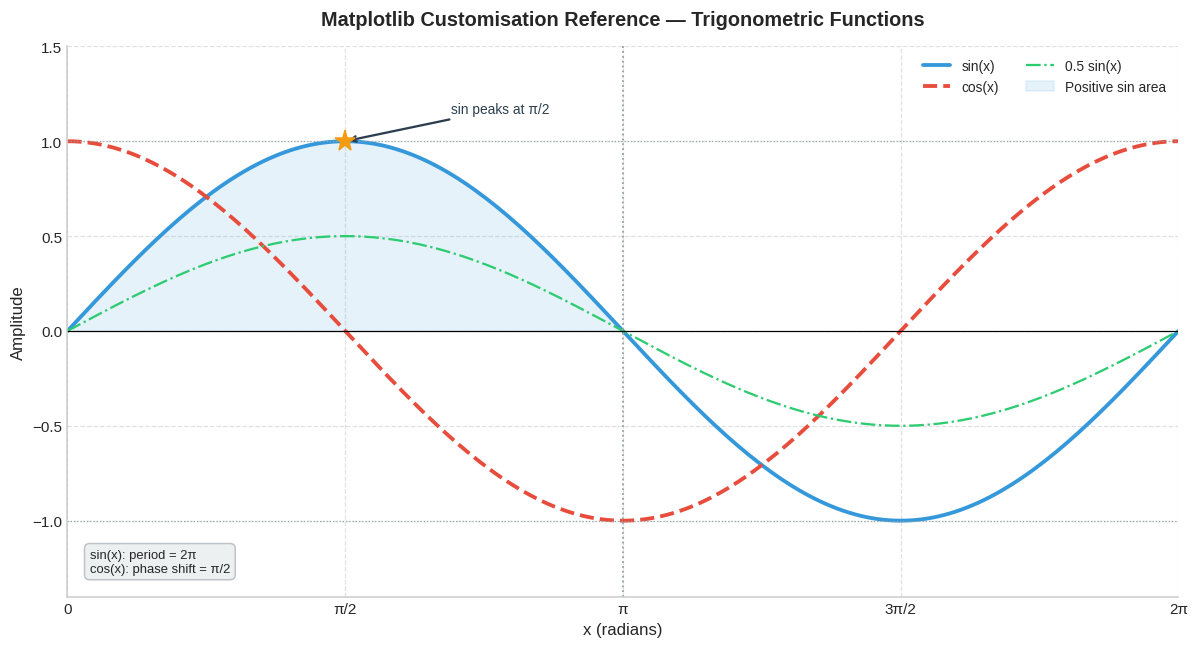

In [ ]:
# ── Customisation showcase — annotated reference chart ────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

x = np.linspace(0, 2 * np.pi, 200)   # 200 evenly spaced points from 0 to 2π

# ── Lines with varied styles ──────────────────────────────────────────────────
ax.plot(x, np.sin(x),       color="#3498db", linewidth=2.5, linestyle="-",
        label="sin(x)")                            # solid line
ax.plot(x, np.cos(x),       color="#e74c3c", linewidth=2.5, linestyle="--",
        label="cos(x)")                            # dashed line
ax.plot(x, np.sin(x) * 0.5, color="#2ecc71", linewidth=1.5, linestyle="-.",
        label="0.5 sin(x)")                        # dash-dot line

# ── Fill between sin and 0 ────────────────────────────────────────────────────
ax.fill_between(
    x,
    np.sin(x),     # upper boundary
    0,             # lower boundary (y=0)
    where=(np.sin(x) > 0),   # only fill positive area
    alpha=0.12,
    color="#3498db",
    label="Positive sin area"
)

# ── Horizontal / vertical reference lines ─────────────────────────────────────
ax.axhline(0,              color="black",   linewidth=0.8, linestyle="-")  # y=0
ax.axvline(np.pi,          color="#95a5a6", linewidth=1.2, linestyle=":")
ax.axhline(1,              color="#95a5a6", linewidth=0.8, linestyle=":")
ax.axhline(-1,             color="#95a5a6", linewidth=0.8, linestyle=":")

# ── Annotation with an arrow ──────────────────────────────────────────────────
ax.annotate(
    "sin peaks at π/2",          # annotation text
    xy=(np.pi / 2, 1.0),         # point being annotated
    xytext=(np.pi / 2 + 0.6, 1.15),  # where the text label sits
    arrowprops=dict(
        arrowstyle="->",         # arrow head style
        color="#2c3e50",
        lw=1.5
    ),
    fontsize=9, color="#2c3e50"
)

# ── A single point marker on the plot ─────────────────────────────────────────
ax.plot(np.pi / 2, 1.0, marker="*", markersize=14,
        color="#f39c12", zorder=5)   # zorder=5 draws on top of everything

# ── Title and axis labels ─────────────────────────────────────────────────────
ax.set_title("Matplotlib Customisation Reference — Trigonometric Functions",
             fontsize=13, fontweight="bold", pad=14)
ax.set_xlabel("x (radians)", fontsize=11)
ax.set_ylabel("Amplitude",   fontsize=11)

# ── Custom x-tick positions and labels — replace numerics with π notation ─────
ax.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax.set_xticklabels(["0", "π/2", "π", "3π/2", "2π"], fontsize=10)

# ── Axis limits ───────────────────────────────────────────────────────────────
ax.set_xlim(0, 2 * np.pi)
ax.set_ylim(-1.4, 1.5)

# ── Legend — positioned, with custom frame ────────────────────────────────────
ax.legend(
    loc="upper right",
    fontsize=9,
    ncol=2,            # arrange legend entries in 2 columns
    framealpha=0.92,
    edgecolor="#cccccc"
)

# ── Gridlines (style override for this specific ax) ──────────────────────────
ax.grid(True, linestyle="--", alpha=0.35, color="#aaaaaa")

# ── Spine visibility ─────────────────────────────────────────────────────────
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# ── Text box (good for displaying stats on the chart) ────────────────────────
stats_text = "sin(x): period = 2π\ncos(x): phase shift = π/2"
ax.text(
    0.02, 0.04,              # (x, y) in axes-fraction coordinates (0=left/bottom, 1=right/top)
    stats_text,
    transform=ax.transAxes,  # tell Matplotlib these are axes fractions, not data units
    fontsize=8.5,
    verticalalignment="bottom",
    bbox=dict(boxstyle="round,pad=0.4", facecolor="#ecf0f1", edgecolor="#bdc3c7")
)

fig.tight_layout()
plt.show()

### Quick-Reference: The Most-Used Customisation Methods

| What you want to change | Method / Argument |
|------------------------|-------------------|
| Title | `ax.set_title("text", fontsize=, fontweight=, pad=)` |
| Axis label | `ax.set_xlabel()` / `ax.set_ylabel()` |
| Axis limits | `ax.set_xlim(lo, hi)` / `ax.set_ylim(lo, hi)` |
| Tick positions | `ax.set_xticks([...])` / `ax.set_yticks([...])` |
| Tick labels | `ax.set_xticklabels([...], rotation=, fontsize=)` |
| Tick format | `ax.xaxis.set_major_formatter(mticker.FuncFormatter(fn))` |
| Legend | `ax.legend(loc=, fontsize=, ncol=, framealpha=)` |
| Grid | `ax.grid(True, linestyle=, alpha=, color=)` |
| Remove spine | `ax.spines["top"].set_visible(False)` |
| Horizontal line | `ax.axhline(y=, color=, linestyle=, linewidth=)` |
| Vertical line | `ax.axvline(x=, ...)` |
| Shaded region (vertical) | `ax.axvspan(xmin, xmax, alpha=, color=)` |
| Fill between two curves | `ax.fill_between(x, y1, y2, where=, alpha=, color=)` |
| Arrow annotation | `ax.annotate(text, xy=, xytext=, arrowprops=)` |
| Text box | `ax.text(x, y, text, transform=ax.transAxes, bbox={})` |
| Figure size | `plt.subplots(figsize=(width, height))` |
| Save figure | `fig.savefig("file.png", dpi=150, bbox_inches="tight")` |

---
## Section 8 — Multi-Panel Figures: `plt.subplots()` Layout Control

### 📖 The Logic

`plt.subplots(nrows, ncols)` creates a grid of `Axes` objects in one call. The return value depends on the grid size:

```python
fig, ax           = plt.subplots(1, 1)   # single Axes object
fig, axes         = plt.subplots(1, 3)   # 1-D array of 3 Axes
fig, axes         = plt.subplots(2, 3)   # 2-D array, shape (2, 3)
fig, (ax1, ax2)   = plt.subplots(1, 2)   # tuple unpacking — two named Axes
fig, ((a,b),(c,d))= plt.subplots(2, 2)   # 2×2 unpacking
```

Key layout parameters of `plt.subplots()`:

| Parameter | What it does |
|-----------|--------------|
| `figsize=(w, h)` | Figure width and height in inches |
| `sharex=True` | All subplots share the same x-axis scale |
| `sharey=True` | All subplots share the same y-axis scale |
| `squeeze=False` | Always return a 2-D array even for 1-row or 1-col grids |

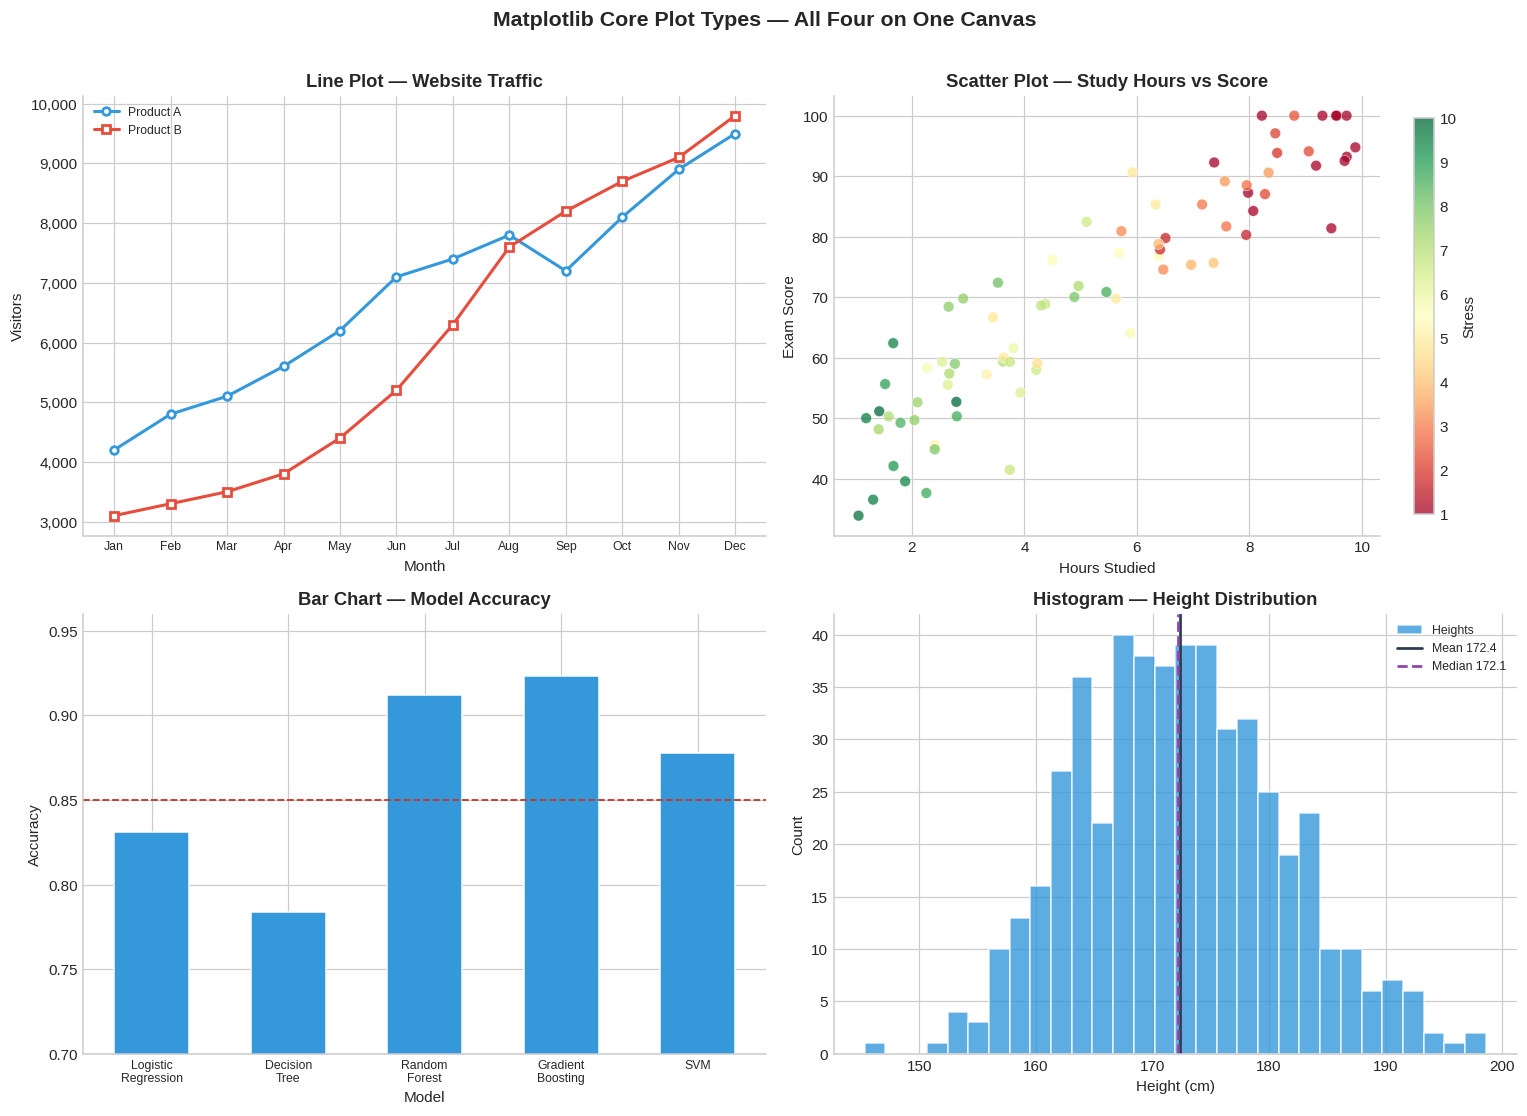

All four core plot types in a single 2×2 OO figure.
Each ax_ variable controls exactly its own panel — no ambiguity.


In [ ]:
# ── All four core plot types on one canvas ────────────────────────────────────
fig, axes = plt.subplots(
    nrows=2, ncols=2,    # 2×2 grid
    figsize=(14, 10),
    sharex=False,        # each subplot manages its own x-axis
    sharey=False
)
fig.suptitle("Matplotlib Core Plot Types — All Four on One Canvas",
             fontsize=14, fontweight="bold", y=1.01)

# Unpack the 2×2 array into individual named axes
(ax_line, ax_scatter), (ax_bar, ax_hist) = axes

# ══════════ Top-Left: Line Plot ════════════════════════════════════════════
ax_line.plot(month_idx, visitors_a, color="#3498db", linewidth=2,
             marker="o", markersize=5, markerfacecolor="white",
             markeredgecolor="#3498db", markeredgewidth=1.8, label="Product A")
ax_line.plot(month_idx, visitors_b, color="#e74c3c", linewidth=2,
             marker="s", markersize=5, markerfacecolor="white",
             markeredgecolor="#e74c3c", markeredgewidth=1.8, label="Product B")
ax_line.set_title("Line Plot — Website Traffic", fontweight="bold")
ax_line.set_xlabel("Month")
ax_line.set_ylabel("Visitors")
ax_line.set_xticks(month_idx)
ax_line.set_xticklabels(months, fontsize=8)
ax_line.yaxis.set_major_formatter(
    plt.matplotlib.ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax_line.legend(fontsize=8)
ax_line.spines["top"].set_visible(False)
ax_line.spines["right"].set_visible(False)

# ══════════ Top-Right: Scatter Plot ═══════════════════════════════════════
sc2 = ax_scatter.scatter(hours, scores, c=stress, cmap="RdYlGn",
                          s=50, alpha=0.75, edgecolors="white",
                          linewidths=0.4, vmin=1, vmax=10)
ax_scatter.set_title("Scatter Plot — Study Hours vs Score", fontweight="bold")
ax_scatter.set_xlabel("Hours Studied")
ax_scatter.set_ylabel("Exam Score")
ax_scatter.spines["top"].set_visible(False)
ax_scatter.spines["right"].set_visible(False)
fig.colorbar(sc2, ax=ax_scatter, label="Stress", shrink=0.9)

# ══════════ Bottom-Left: Bar Chart ════════════════════════════════════════
x_bar = np.arange(len(models))
ax_bar.bar(x_bar, accuracy, width=0.55, color="#3498db", edgecolor="white")
ax_bar.axhline(0.85, color="#c0392b", linestyle="--", linewidth=1.2)
ax_bar.set_title("Bar Chart — Model Accuracy", fontweight="bold")
ax_bar.set_xlabel("Model")
ax_bar.set_ylabel("Accuracy")
ax_bar.set_xticks(x_bar)
ax_bar.set_xticklabels(models, fontsize=8)
ax_bar.set_ylim(0.70, 0.96)
ax_bar.spines["top"].set_visible(False)
ax_bar.spines["right"].set_visible(False)

# ══════════ Bottom-Right: Histogram ════════════════════════════════════════
ax_hist.hist(heights, bins=30, color="#3498db", edgecolor="white",
             alpha=0.8, label="Heights")
ax_hist.axvline(heights.mean(),   color="#2c3e50",  linewidth=1.8,
                label=f"Mean {heights.mean():.1f}")
ax_hist.axvline(np.median(heights), color="#8e44ad", linewidth=1.8,
                linestyle="--", label=f"Median {np.median(heights):.1f}")
ax_hist.set_title("Histogram — Height Distribution", fontweight="bold")
ax_hist.set_xlabel("Height (cm)")
ax_hist.set_ylabel("Count")
ax_hist.legend(fontsize=8)
ax_hist.spines["top"].set_visible(False)
ax_hist.spines["right"].set_visible(False)

fig.tight_layout()
plt.show()

print("All four core plot types in a single 2×2 OO figure.")
print("Each ax_ variable controls exactly its own panel — no ambiguity.")

---
## Section 9 — Saving Figures

### 📖 The Logic

`fig.savefig()` saves the figure to disk. Always call it **before** `plt.show()` — `show()` clears the figure from memory. Key parameters:

| Parameter | Recommended value | Why |
|-----------|------------------|-----|
| `dpi` | 150 (screen), 300 (print) | Controls pixel density — higher = sharper but larger file |
| `bbox_inches` | `'tight'` | Crops white border and prevents labels from being clipped |
| `format` | inferred from extension | `.png` for raster, `.pdf`/`.svg` for vector |

Saved to  : /tmp/nb8_line_plot.png
File size : 48,407 bytes


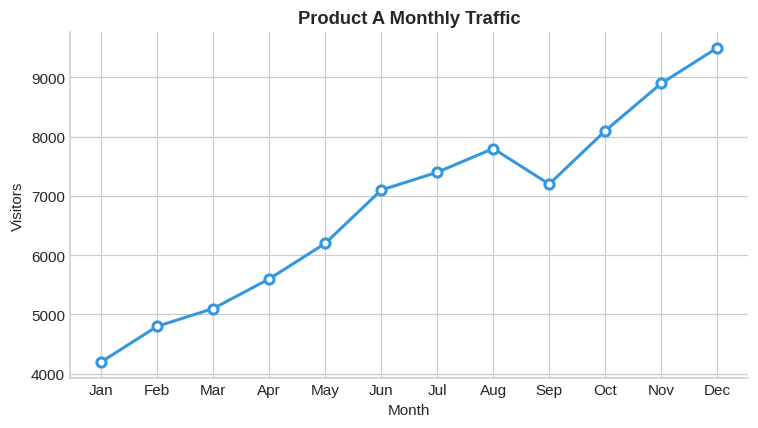

In [ ]:
# ── Demonstrate saving a figure ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(month_idx, visitors_a, color="#3498db", linewidth=2,
        marker="o", markersize=6, markerfacecolor="white",
        markeredgecolor="#3498db", markeredgewidth=2)
ax.set_title("Product A Monthly Traffic", fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Visitors")
ax.set_xticks(month_idx)
ax.set_xticklabels(months)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
fig.tight_layout()

# ── Save BEFORE plt.show() ────────────────────────────────────────────────────
# bbox_inches='tight' → auto-crop to content, no clipped labels
# dpi=150             → good screen resolution (use 300 for publication)
save_path = "/tmp/nb8_line_plot.png"
fig.savefig(save_path, dpi=150, bbox_inches="tight", facecolor="white")

import os
print(f"Saved to  : {save_path}")
print(f"File size : {os.path.getsize(save_path):,} bytes")

plt.show()   # called AFTER savefig

---
## ✅ Notebook Summary & Key Takeaways

| Concept | Core rule | Gotcha to remember |
|---------|-----------|--------------------|
| **OO vs state-based** | Always use `fig, ax = plt.subplots()` | `plt.plot()` is fine for one-liners; breaks with multi-panel figures |
| **Figure vs Axes** | Figure = canvas; Axes = one plot panel | An Axes is always inside a Figure; not the other way round |
| **`ax.set_*()` prefix** | OO methods use `set_title`, `set_xlabel`, etc. | `plt.title()` (state) ≠ `ax.set_title()` (OO) — don't mix them |
| **Line plot** | Use for ordered / time-series data | Wrong for unordered categories — bars are better there |
| **Scatter plot** | Use for continuous x vs continuous y | Pass `c=` array + `cmap=` to encode a third variable as colour |
| **Bar chart** | Use for categorical comparisons | Grouped bars: offset `x ± width/2` for each group |
| **Histogram** | Use for continuous variable distributions | Too few bins hides shape; `bins=int(√n)` is a safe starting point |
| **`fig.tight_layout()`** | Prevents overlapping titles / labels | Call it just before `plt.show()` or `fig.savefig()` |
| **`fig.savefig()`** | Must be called **before** `plt.show()` | `show()` clears the figure from memory |
| **`ax.spines["top"].set_visible(False)`** | Remove top/right borders for cleaner look | Apply to both `top` and `right` spines together |

---

